In [27]:
import pickle
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [28]:
# get dataloader
import sys
sys.path.insert(0, '../')
sys.path.insert(0, "/data/robert/CP-X-Prediction/Intersection-Code/Intersection-MTR/Prediction/MTR")
from mtr.datasets import build_dataloader
from mtr.config import cfg, cfg_from_list, cfg_from_yaml_file, log_config_to_file
from mtr.utils import common_utils
import datetime
from pathlib import Path

cfg_file = '/data/robert/CP-X-Prediction/Intersection-Code/Intersection-MTR/Prediction/MTR/tools/cfgs/challenge/mtr-training-CPX-Prediction.yaml'
log_file = "/data/robert/CP-X-Prediction/Intersection-Code/Intersection-MTR/Visualization/cpx_mtr_viz/cluster_log.txt"
cfg_from_yaml_file(cfg_file, cfg)
logger = common_utils.create_logger(log_file, rank=cfg.LOCAL_RANK)
train_set, train_loader, train_sampler = build_dataloader(
    dataset_cfg=cfg.DATA_CONFIG,
    batch_size=80,
    dist=False, workers=2,
    logger=logger,
    training=True,
    merge_all_iters_to_one_epoch=False,
    total_epochs=10,
    add_worker_init_fn=None,
)

2025-12-09 09:19:56,024   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_training_infos.pkl
2025-12-09 09:19:56,024   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_training_infos.pkl
2025-12-09 09:19:56,024   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_training_infos.pkl
2025-12-09 09:19:56,024   INFO  Start to load infos from /data/dataset/CP-X/data/waymo/processed_scenarios_training_infos.pkl


2025-12-09 09:20:12,789   INFO  Total scenes before filters: 243498
2025-12-09 09:20:12,789   INFO  Total scenes before filters: 243498
2025-12-09 09:20:12,789   INFO  Total scenes before filters: 243498
2025-12-09 09:20:12,789   INFO  Total scenes before filters: 243498
2025-12-09 09:20:15,282   INFO  Total scenes after filter_info_by_object_type: 243498
2025-12-09 09:20:15,282   INFO  Total scenes after filter_info_by_object_type: 243498
2025-12-09 09:20:15,282   INFO  Total scenes after filter_info_by_object_type: 243498
2025-12-09 09:20:15,282   INFO  Total scenes after filter_info_by_object_type: 243498
2025-12-09 09:20:16,265   INFO  Total scenes after filters: 243498
2025-12-09 09:20:16,265   INFO  Total scenes after filters: 243498
2025-12-09 09:20:16,265   INFO  Total scenes after filters: 243498
2025-12-09 09:20:16,265   INFO  Total scenes after filters: 243498


In [29]:
# Access the dataset from the dataloader
dataset_from_dataloader = train_loader.dataset
# Now you can use dataset_from_dataloader as needed
print(f"Dataset: {dataset_from_dataloader}")
print(f"Number of samples in the dataset: {len(dataset_from_dataloader)}")

Dataset: <mtr.datasets.waymo.waymo_dataset.WaymoDataset object at 0x7f7a7e60ae30>
Number of samples in the dataset: 243498


In [30]:
all_center_gt_trajs = []
all_center_gt_trajs_mask = []
all_center_objects_type = []
all_scenario_id = []

# Iterate over the DataLoader
for i, batch in enumerate(train_loader):

    center_gt_trajs = batch['input_dict']['center_gt_trajs']
    center_gt_trajs_mask = batch['input_dict']['center_gt_trajs_mask']
    center_objects_type = batch['input_dict']['center_objects_type']
    scenario_id = batch['input_dict']['scenario_id']

    all_center_gt_trajs.append(center_gt_trajs)
    all_center_gt_trajs_mask.append(center_gt_trajs_mask)
    all_center_objects_type.append(center_objects_type)
    all_scenario_id.append(scenario_id)
    
    if i == 5:
        break


In [31]:
all_center_gt_trajs_mask_concat = torch.cat(all_center_gt_trajs_mask, dim=0)
all_center_gt_trajs_concat = torch.cat(all_center_gt_trajs, dim=0)
all_center_objects_type_concat = np.concatenate(all_center_objects_type)
print(all_center_gt_trajs_concat.shape, all_center_gt_trajs_mask_concat.shape, all_center_objects_type_concat.shape)

torch.Size([2211, 80, 4]) torch.Size([2211, 80]) (2211,)


In [32]:
intention_points_dict = {}

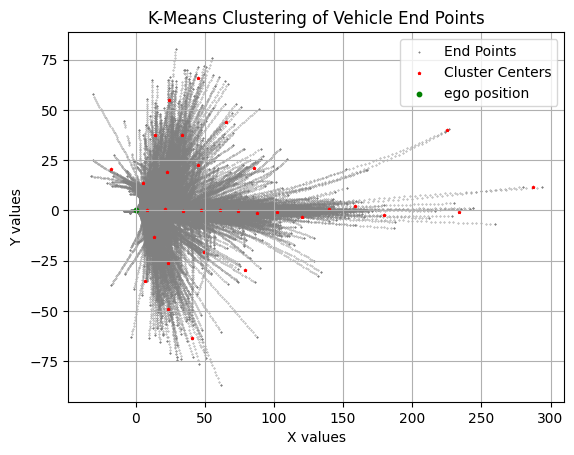

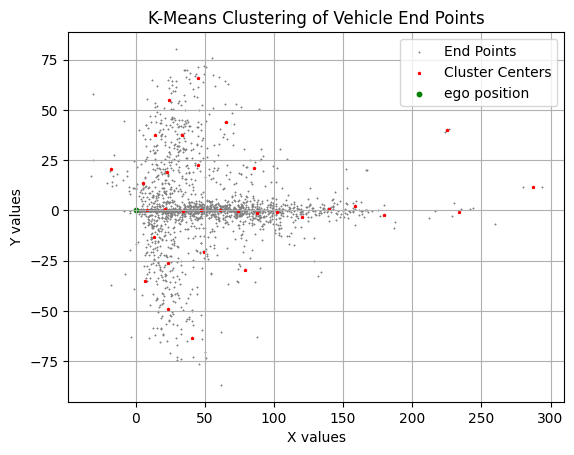

In [33]:
# get intention points for TYPE_VEHICLE
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_VEHICLE':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32  #64

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
vehicle_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_VEHICLE'] = vehicle_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_vehicle_mask = (all_center_objects_type_concat == 'TYPE_VEHICLE')
filtered_vehicle_trajs = all_center_gt_trajs_concat[filtered_vehicle_mask]

filtered_vehicle_trajs = filtered_vehicle_trajs.reshape(-1, 4)
traj_x = filtered_vehicle_trajs[:, 0].cpu().numpy()
traj_y = filtered_vehicle_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(vehicle_cluster_centers[:, 0], vehicle_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Vehicle End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(vehicle_cluster_centers[:, 0], vehicle_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Vehicle End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

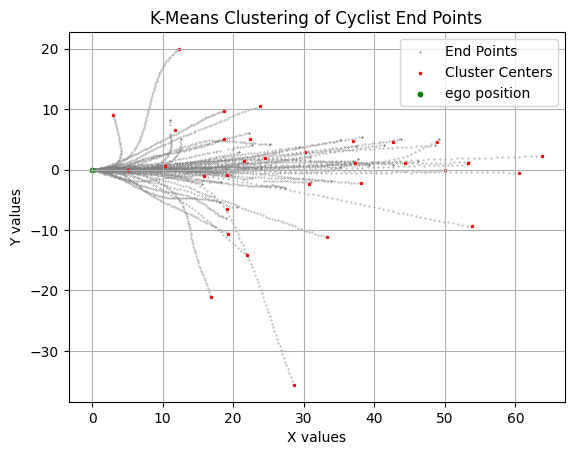

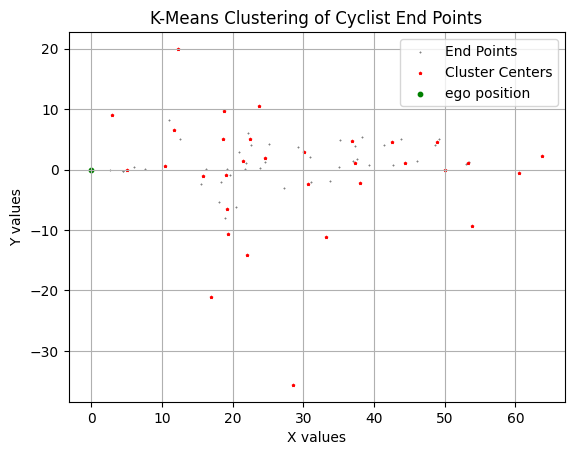

In [34]:
# get intention points for TYPE_CYCLIST
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_CYCLIST':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
cyclist_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_CYCLIST'] = cyclist_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_cyclist_mask = (all_center_objects_type_concat == 'TYPE_CYCLIST')
filtered_cyclist_trajs = all_center_gt_trajs_concat[filtered_cyclist_mask]

filtered_cyclist_trajs = filtered_cyclist_trajs.reshape(-1, 4)
traj_x = filtered_cyclist_trajs[:, 0].cpu().numpy()
traj_y = filtered_cyclist_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(cyclist_cluster_centers[:, 0], cyclist_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Cyclist End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(cyclist_cluster_centers[:, 0], cyclist_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Cyclist End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

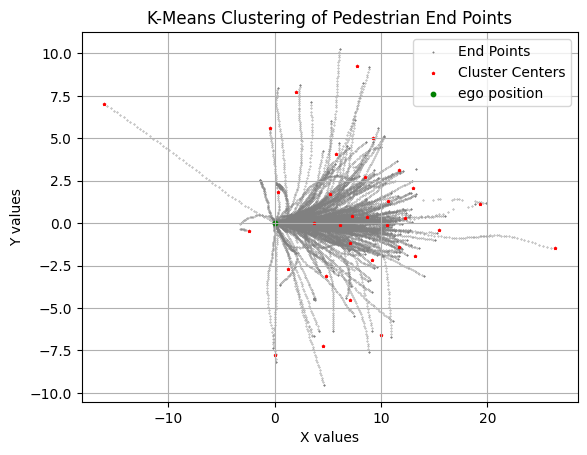

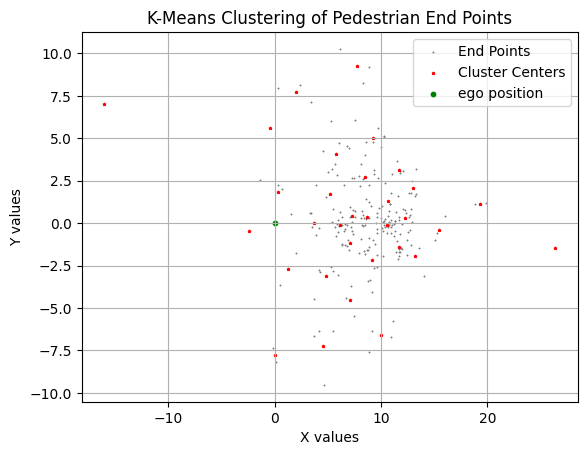

In [35]:
# get intention points for TYPE_PEDESTRIAN
num_trajs = all_center_gt_trajs_concat.shape[0]
end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_PEDESTRIAN':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
pedestrian_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_PEDESTRIAN'] = pedestrian_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_pedestrian_mask = (all_center_objects_type_concat == 'TYPE_PEDESTRIAN')
filtered_pedestrian_trajs = all_center_gt_trajs_concat[filtered_pedestrian_mask]

filtered_pedestrian_trajs = filtered_pedestrian_trajs.reshape(-1, 4)
traj_x = filtered_pedestrian_trajs[:, 0].cpu().numpy()
traj_y = filtered_pedestrian_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Pedestrian End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Pedestrian End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
print(end_points)

[[ 3.70484734e+00 -6.65550232e+00]
 [ 5.51612091e+00 -6.35402966e+00]
 [ 2.96169281e-01  7.93439388e+00]
 [ 7.34827805e+00 -6.70533180e-01]
 [ 1.12865400e+01  1.45159602e-01]
 [ 8.82977200e+00  3.11375141e-01]
 [ 9.75944328e+00  2.63943267e+00]
 [ 6.80929232e+00  4.54680300e+00]
 [ 6.07387733e+00  4.74457312e+00]
 [ 1.15633802e+01 -2.11734557e+00]
 [ 1.05339403e+01 -5.54564476e-01]
 [ 7.05847454e+00  9.30860996e-01]
 [ 3.86497235e+00 -7.13338375e-01]
 [ 9.37108231e+00  2.91894579e+00]
 [ 5.44290304e+00  9.40363705e-02]
 [ 7.39408064e+00  7.51418769e-01]
 [ 1.08325109e+01 -7.78293610e-03]
 [ 5.84086990e+00  2.85505962e+00]
 [ 6.80506039e+00 -1.35619640e-01]
 [ 1.08638668e+01  1.11273837e+00]
 [ 1.19478178e+01 -7.28225708e-02]
 [ 8.37393379e+00  2.64035940e+00]
 [ 1.02231083e+01 -4.38048124e-01]
 [ 8.30814171e+00 -1.47342861e-01]
 [ 4.29789734e+00 -2.87586689e+00]
 [ 1.01074762e+01  9.98154402e-01]
 [ 8.84444427e+00 -8.54350805e-01]
 [ 8.12862778e+00  3.18665683e-01]
 [ 8.87899494e+00  2

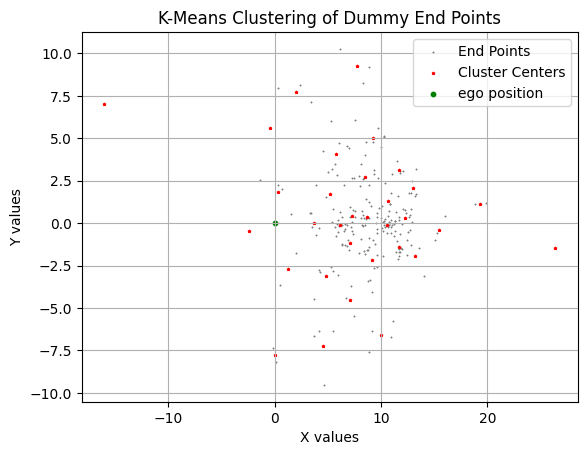

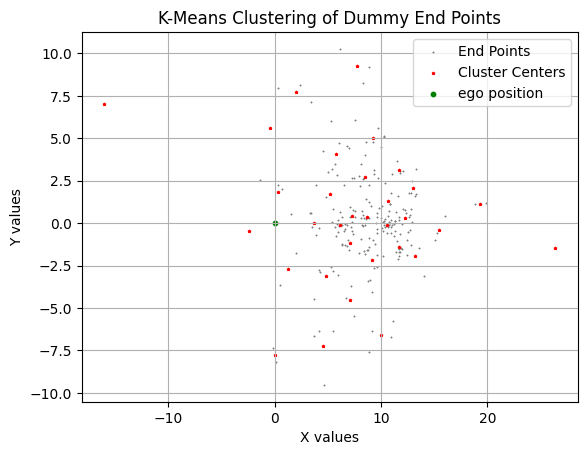

In [37]:
# get intention points for TYPE_PEDESTRIAN
num_trajs = all_center_gt_trajs_concat.shape[0]
# end_points = []

for i in range(num_trajs):
    # Masked selection
    if all_center_objects_type_concat[i] != 'TYPE_DUMMY':
        continue

    valid_mask = all_center_gt_trajs_mask_concat[i].bool()
    valid_trajs = all_center_gt_trajs_concat[i, valid_mask]

    
    if valid_trajs.shape[0] <= 0: 
        print("No valid points in trajectory %d" % i)
        continue

    end_point = valid_trajs[-1].cpu().numpy()

    end_points.append([end_point[0], end_point[1]])
end_points = np.array(end_points)

# Number of clusters
num_clusters = 32

# Apply KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(end_points)
# Get cluster centers
pedestrian_cluster_centers = kmeans.cluster_centers_
intention_points_dict['TYPE_DUMMY'] = pedestrian_cluster_centers
# Filter trajectories where the object type is TYPE_VEHICLE
filtered_pedestrian_mask = (all_center_objects_type_concat == 'TYPE_DUMMY')
filtered_pedestrian_trajs = all_center_gt_trajs_concat[filtered_pedestrian_mask]

filtered_pedestrian_trajs = filtered_pedestrian_trajs.reshape(-1, 4)
traj_x = filtered_pedestrian_trajs[:, 0].cpu().numpy()
traj_y = filtered_pedestrian_trajs[:, 1].cpu().numpy()
plt.scatter(traj_x, traj_y, s=0.1, color='grey')

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Dummy End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(end_points[:, 0], end_points[:, 1], s=0.1, color='grey', marker='*', label='End Points')
plt.scatter(pedestrian_cluster_centers[:, 0], pedestrian_cluster_centers[:, 1], s=3, color='red', marker='*', label='Cluster Centers')
plt.scatter([0], [0], s=10, color='green', label='ego position')
plt.title("K-Means Clustering of Dummy End Points")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()